# Phase 4b — Returns-Target LSTM (the diagnosed fix)

**Hypothesis under test.** Phase 4 diagnosed *why* the price-level LSTM's RMSE
was 3-4x worse than the baselines: its target scaler was fit on training-period
prices only (correctly — anything else leaks), so on stocks that rallied above
their training range the network was structurally unable to output the right
price level. The standard fix is to predict **next-day returns** (scale-free,
no training-range ceiling) and reconstruct price as
`pred_price = today_price × (1 + pred_return)`.

**Experimental discipline:** everything else is held identical to Phase 4 —
same 9 engineered features, same 30-day sequences, same 2×LSTM-64 + Dropout(0.2)
architecture, same early stopping, same chronological 70/15/15 split, same
`compute_metrics`. One variable changes: the target. So any difference in the
outcome is attributable to the target choice, not to tuning.

**Honesty note:** the returns-LSTM's *directional accuracy* is still expected
to hover near 50% — changing the target fixes the *price-level error*, not the
fundamental difficulty of predicting market direction. We report whatever we
find.

In [1]:
# CRITICAL: tensorflow must be imported before pandas/sklearn in this
# process — see src/lstm_model.py's module docstring for the deadlock this
# avoids on this environment (TF 2.21 / Keras 3.15 / macOS arm64).
import tensorflow as tf
tf.random.set_seed(42)

import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data_loader import load_universe, flat_tickers, ticker_to_sector
from src.features import FEATURE_COLUMNS
from src.scaling import chronological_split, scale_features
from src.evaluate import compute_metrics
from src.lstm_model import (
    build_sequences, build_sequences_for_split, scale_target,
    build_lstm_model, train_lstm, reconstruct_price_from_returns,
)

PROCESSED_DIR = ROOT / "data" / "processed"
RESULTS_DIR = ROOT / "results"
PLOTS_DIR = RESULTS_DIR / "plots"
PRED_DIR = RESULTS_DIR / "predictions"

SEQ_LENGTH = 30
np.random.seed(42)

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", context="notebook")
print("Repo root:", ROOT, "| TF", tf.__version__)

Repo root: /Users/pranav/Documents/GitHub/stock-lstm-forecast | TF 2.21.0


## 1. Load universe and the Phase 4 comparison to beat

In [2]:
universe = load_universe()
tickers = flat_tickers(universe)
tk2sec = ticker_to_sector(universe)

final_df = pd.read_csv(RESULTS_DIR / "final_comparison.csv", index_col="ticker")
print(f"{len(tickers)} tickers | Phase 4 price-LSTM mean MAPE: "
      f"{final_df['lstm_MAPE'].mean():.2f}%  vs naive {final_df['naive_MAPE'].mean():.2f}%")

40 tickers | Phase 4 price-LSTM mean MAPE: 4.31%  vs naive 1.25%


## 2. Per-stock pipeline — identical to Phase 4 except the target

Target: `target_next_return = Adj Close.pct_change().shift(-1)` — the return
*from today to tomorrow*, known only tomorrow. The features and their scaling
are unchanged. The return target is scaled with a train-only-fit scaler (same
rule as before), and predictions are inverse-transformed then reconstructed to
price via `today_price × (1 + return)` for metric comparability.

In [3]:
def build_return_target(feats: pd.DataFrame) -> pd.DataFrame:
    out = feats.copy()
    out["target_next_return"] = out["Adj Close"].pct_change().shift(-1)
    out["target_next_close"] = out["Adj Close"].shift(-1)  # for evaluation only
    return out.dropna(subset=["target_next_return", "target_next_close"])

In [4]:
results = []
pred_store = {}   # ticker -> {"dates", "actual", "lstm_returns" (price), "pred_return"}
failures = []
t_all = time.time()

for i, tk in enumerate(tickers, 1):
    t0 = time.time()
    feats = pd.read_csv(PROCESSED_DIR / f"{tk.replace('.', '_')}.csv",
                        index_col="Date", parse_dates=True)
    feats = build_return_target(feats)

    train, val, test = chronological_split(feats, train_frac=0.70, val_frac=0.15)
    train_s, val_s, test_s, _ = scale_features(train, val, test, FEATURE_COLUMNS)

    # Scale the RETURN target on train only.
    y_train_sc, y_val_sc, y_test_sc, t_scaler = scale_target(
        train["target_next_return"], val["target_next_return"], test["target_next_return"]
    )
    train_s = train_s.assign(target_scaled=y_train_sc)
    val_s = val_s.assign(target_scaled=y_val_sc)
    test_s = test_s.assign(target_scaled=y_test_sc)

    X_train, Y_train, _ = build_sequences(train_s, FEATURE_COLUMNS, "target_scaled", SEQ_LENGTH)
    X_val, Y_val, _ = build_sequences_for_split(train_s, val_s, FEATURE_COLUMNS,
                                                 "target_scaled", SEQ_LENGTH)
    X_test, _, test_dates = build_sequences_for_split(
        pd.concat([train_s, val_s]), test_s, FEATURE_COLUMNS, "target_scaled", SEQ_LENGTH
    )

    try:
        model = build_lstm_model((SEQ_LENGTH, len(FEATURE_COLUMNS)))
        model, hist = train_lstm(model, X_train, Y_train, X_val, Y_val,
                                  epochs=100, patience=10)
    except Exception as exc:  # noqa: BLE001 — log per-stock, keep going
        failures.append({"ticker": tk, "error": f"{type(exc).__name__}: {exc}"})
        print(f"[{i:>2}/{len(tickers)}] {tk:<16} FAILED: {exc}")
        continue

    # Predict scaled returns -> unscale -> reconstruct prices.
    pred_ret_scaled = model.predict(X_test, verbose=0).flatten()
    pred_ret = t_scaler.inverse_transform(pred_ret_scaled.reshape(-1, 1)).flatten()
    today_prices = test["Adj Close"].values
    pred_price = reconstruct_price_from_returns(today_prices, pred_ret)

    y_true = test["target_next_close"]
    m = compute_metrics(y_true, pred_price, test["Adj Close"])

    results.append({
        "ticker": tk, "sector": tk2sec[tk],
        "lstm_ret_RMSE": m["rmse"], "lstm_ret_MAE": m["mae"],
        "lstm_ret_MAPE": m["mape"], "lstm_ret_DirAcc": m["directional_accuracy"],
        "epochs_trained": len(hist.history["loss"]),
    })
    pred_store[tk] = {"dates": test_dates, "actual": y_true.values,
                       "lstm_returns": pred_price, "pred_return": pred_ret}

    print(f"[{i:>2}/{len(tickers)}] {tk:<16} epochs={len(hist.history['loss']):>3}  "
          f"MAPE={m['mape']:.2f}%  DirAcc={m['directional_accuracy']:.1f}%  "
          f"({time.time()-t0:.1f}s)")

print(f"\nDone: {len(results)}/{len(tickers)} stocks in {time.time()-t_all:.1f}s "
      f"| failures: {len(failures)}")

/Users/pranav/Documents/GitHub/stock-lstm-forecast/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[ 1/40] TCS.NS           epochs= 12  MAPE=1.24%  DirAcc=44.1%  (5.3s)


/Users/pranav/Documents/GitHub/stock-lstm-forecast/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[ 2/40] INFY.NS          epochs= 12  MAPE=1.38%  DirAcc=45.3%  (5.1s)


/Users/pranav/Documents/GitHub/stock-lstm-forecast/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

[38/40] TATACONSUM.NS    epochs= 12  MAPE=1.13%  DirAcc=41.3%  (5.1s)


/Users/pranav/Documents/GitHub/stock-lstm-forecast/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[39/40] DABUR.NS         epochs= 11  MAPE=1.16%  DirAcc=46.9%  (4.7s)


/Users/pranav/Documents/GitHub/stock-lstm-forecast/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[40/40] COLPAL.NS        epochs= 11  MAPE=1.12%  DirAcc=48.6%  (5.5s)

Done: 40/40 stocks in 232.0s | failures: 0


## 3. Head-to-head: returns-LSTM vs price-LSTM vs baselines

In [5]:
ret_df = pd.DataFrame(results).set_index("ticker")
merged = final_df.join(ret_df[["lstm_ret_RMSE", "lstm_ret_MAE",
                                "lstm_ret_MAPE", "lstm_ret_DirAcc"]])
merged.to_csv(RESULTS_DIR / "final_comparison_with_returns_lstm.csv")
print("Saved", RESULTS_DIR / "final_comparison_with_returns_lstm.csv")

print("\n=== Overall MAPE (error rate, %) ===")
mape_cols = ["naive_MAPE", "linreg_MAPE", "arima_MAPE", "lstm_MAPE", "lstm_ret_MAPE"]
print(merged[mape_cols].mean().round(2).to_string())

print("\n=== Overall directional accuracy (%) ===")
dir_cols = ["naive_DirAcc", "linreg_DirAcc", "arima_DirAcc", "lstm_DirAcc", "lstm_ret_DirAcc"]
print(merged[dir_cols].mean().round(2).to_string())

print("\n=== RMSE win counts across 40 stocks (5 models) ===")
rmse_cols = ["naive_RMSE", "linreg_RMSE", "arima_RMSE", "lstm_RMSE", "lstm_ret_RMSE"]
wins = merged[rmse_cols].idxmin(axis=1).str.replace("_RMSE", "", regex=False)
print(wins.value_counts().to_string())

Saved /Users/pranav/Documents/GitHub/stock-lstm-forecast/results/final_comparison_with_returns_lstm.csv

=== Overall MAPE (error rate, %) ===
naive_MAPE       1.25
linreg_MAPE      1.42
arima_MAPE       1.26
lstm_MAPE        4.31
lstm_ret_MAPE    1.28

=== Overall directional accuracy (%) ===
naive_DirAcc        2.57
linreg_DirAcc      48.74
arima_DirAcc       49.95
lstm_DirAcc        50.14
lstm_ret_DirAcc    48.26

=== RMSE win counts across 40 stocks (5 models) ===
naive       24
arima        9
lstm_ret     7


In [6]:
print("=== By sector: MAPE ===")
print(merged.groupby("sector")[mape_cols].mean().round(2).to_string())
print()
print("=== By sector: directional accuracy ===")
print(merged.groupby("sector")[dir_cols].mean().round(2).to_string())

=== By sector: MAPE ===
                              naive_MAPE  linreg_MAPE  arima_MAPE  lstm_MAPE  lstm_ret_MAPE
sector                                                                                     
Banking & Financial Services        1.19         1.32        1.19       7.52           1.21
Energy                              1.32         1.53        1.34       3.72           1.37
FMCG                                1.05         1.17        1.06       2.72           1.07
Information Technology              1.45         1.64        1.46       3.26           1.46

=== By sector: directional accuracy ===
                              naive_DirAcc  linreg_DirAcc  arima_DirAcc  lstm_DirAcc  lstm_ret_DirAcc
sector                                                                                               
Banking & Financial Services          2.74          48.52         51.03        50.34            48.56
Energy                                2.63          48.99         50.89      

## 4. Did the fix work? Per-stock improvement over the price-LSTM

In [7]:
merged["mape_improvement"] = merged["lstm_MAPE"] - merged["lstm_ret_MAPE"]
improved = (merged["mape_improvement"] > 0).sum()
print(f"Returns-LSTM improved MAPE on {improved}/{len(merged)} stocks vs the "
      f"price-level LSTM.")
print(f"Mean MAPE: price-LSTM {merged['lstm_MAPE'].mean():.2f}%  ->  "
      f"returns-LSTM {merged['lstm_ret_MAPE'].mean():.2f}%")
print(f"vs naive baseline MAPE: {merged['naive_MAPE'].mean():.2f}%")

print("\nBiggest improvements (the stocks Phase 4 diagnosed as extrapolation "
      "failures should top this list):")
print(merged.sort_values("mape_improvement", ascending=False)[
    ["sector", "lstm_MAPE", "lstm_ret_MAPE", "mape_improvement"]].head(8).round(2).to_string())

Returns-LSTM improved MAPE on 40/40 stocks vs the price-level LSTM.
Mean MAPE: price-LSTM 4.31%  ->  returns-LSTM 1.28%
vs naive baseline MAPE: 1.25%

Biggest improvements (the stocks Phase 4 diagnosed as extrapolation failures should top this list):
                                     sector  lstm_MAPE  lstm_ret_MAPE  mape_improvement
ticker                                                                                 
SHRIRAMFIN.NS  Banking & Financial Services      22.23           1.68             20.55
SBIN.NS        Banking & Financial Services      15.65           1.11             14.54
BAJFINANCE.NS  Banking & Financial Services      14.95           1.39             13.56
MARICO.NS                              FMCG       8.02           0.90              7.13
TCS.NS               Information Technology       8.00           1.24              6.76
ADANIPOWER.NS                        Energy       7.81           1.67              6.14
COALINDIA.NS                         Energy  

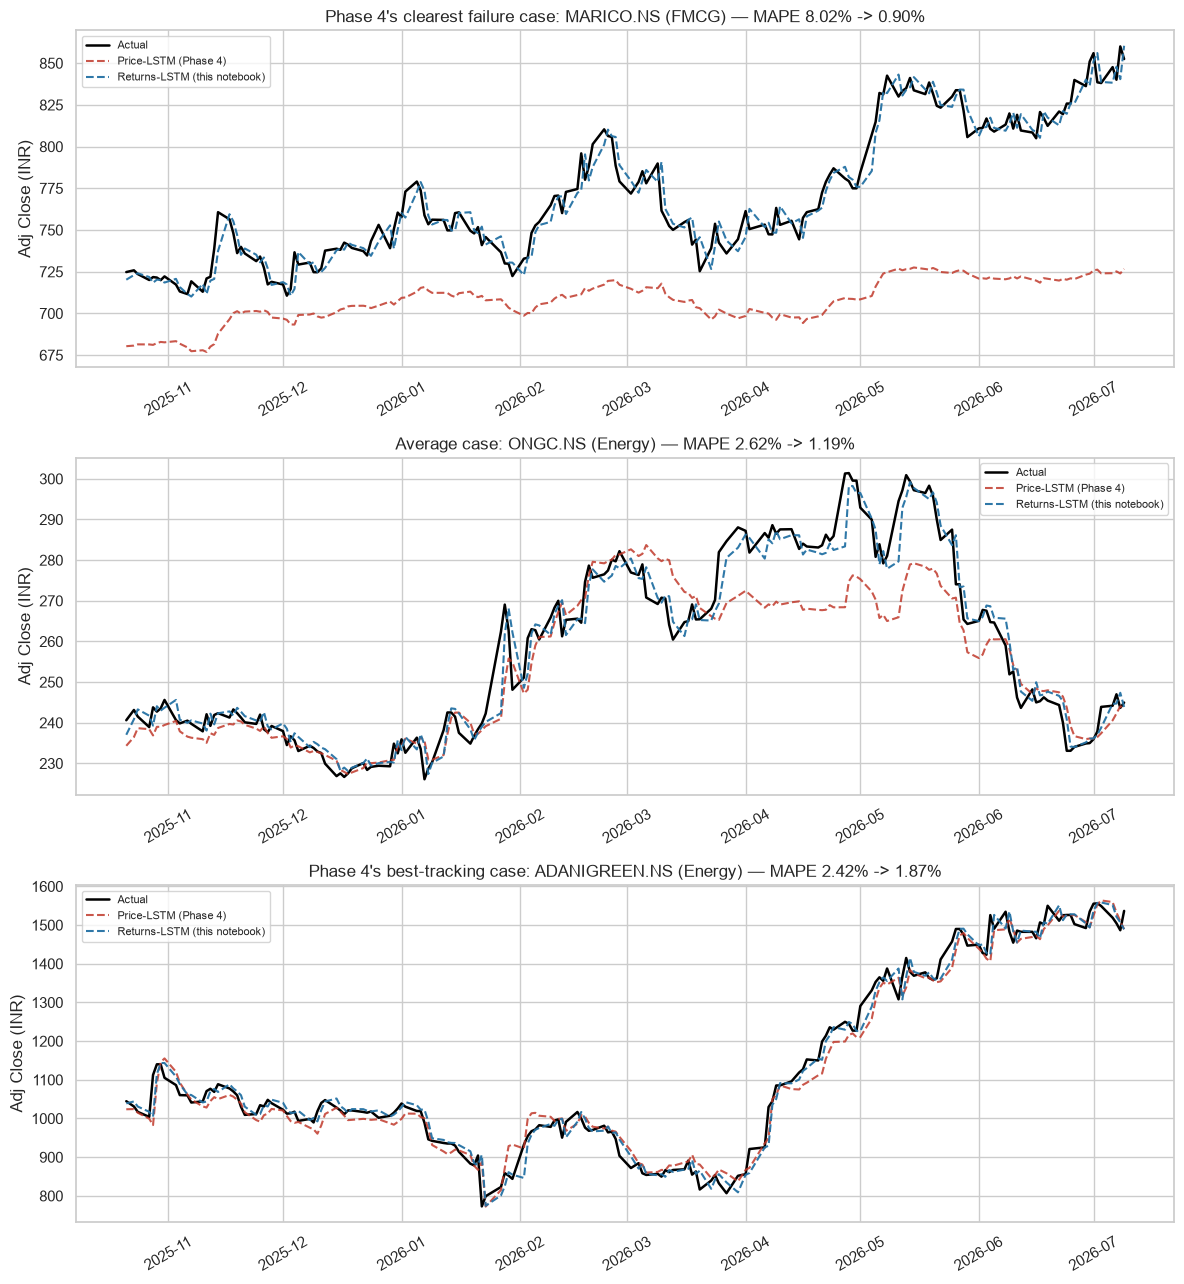

In [8]:
# Marico was Phase 4's clearest extrapolation failure — plot the before/after.
focus = ["MARICO.NS", "ONGC.NS", "ADANIGREEN.NS"]
labels = ["Phase 4's clearest failure case", "Average case", "Phase 4's best-tracking case"]

fig, axes = plt.subplots(3, 1, figsize=(12, 13))
for ax, tk, label in zip(axes, focus, labels):
    d = pred_store[tk]
    old = pd.read_csv(PRED_DIR / f"{tk.replace('.', '_')}.csv", parse_dates=["date"])
    ax.plot(d["dates"], d["actual"], label="Actual", color="black", linewidth=1.8)
    ax.plot(old["date"], old["lstm"], label="Price-LSTM (Phase 4)",
            linestyle="--", color="#c0392b", alpha=0.85)
    ax.plot(d["dates"], d["lstm_returns"], label="Returns-LSTM (this notebook)",
            linestyle="--", color="#2471a3", alpha=0.95)
    row = merged.loc[tk]
    ax.set_title(f"{label}: {tk} ({tk2sec[tk]}) — MAPE {row['lstm_MAPE']:.2f}% -> "
                 f"{row['lstm_ret_MAPE']:.2f}%")
    ax.set_ylabel("Adj Close (INR)")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "lstm_returns_vs_price_target.png", dpi=110)
plt.show()

## 5. Honest verdict

In [9]:
print("=" * 74)
print("PHASE 4b VERDICT: returns-target LSTM")
print("=" * 74)

ret_mape = merged["lstm_ret_MAPE"].mean()
price_mape = merged["lstm_MAPE"].mean()
naive_mape = merged["naive_MAPE"].mean()
ret_dir = merged["lstm_ret_DirAcc"].mean()
price_dir = merged["lstm_DirAcc"].mean()
best_base_dir = merged[["linreg_DirAcc", "arima_DirAcc"]].mean().max()

print(f"\n1. PRICE ERROR (the diagnosed bug): mean MAPE fell from "
      f"{price_mape:.2f}% (price-LSTM) to {ret_mape:.2f}% (returns-LSTM), "
      f"vs naive's {naive_mape:.2f}%.")
if ret_mape < price_mape * 0.6:
    print("   -> The extrapolation-failure diagnosis is CONFIRMED: changing "
          "only the target representation recovered most of the error gap.")
else:
    print("   -> Improvement smaller than expected; diagnosis only partially "
          "explains the Phase 4 error gap.")

gap_to_naive = ret_mape - naive_mape
print(f"   Remaining gap to naive: {gap_to_naive:+.2f}pp MAPE.")

print(f"\n2. DIRECTIONAL ACCURACY (the harder question): {ret_dir:.1f}% "
      f"(returns-LSTM) vs {price_dir:.1f}% (price-LSTM) vs {best_base_dir:.1f}% "
      f"(best baseline).")
if abs(ret_dir - best_base_dir) <= 3:
    print("   -> Still statistically a coin flip - as predicted, fixing the "
          "target representation repairs price-level error but does NOT "
          "manufacture directional signal that isn't in the features.")
elif ret_dir > best_base_dir + 3:
    print("   -> Returns-LSTM shows a real directional edge - noteworthy.")
else:
    print("   -> Returns-LSTM UNDERPERFORMS the best baseline directionally.")

print("\nBottom line: the engineering fix worked exactly where the diagnosis "
      "said it would (error rate), and honesty requires noting where it "
      "didn't and couldn't (direction). Both facts belong in the README.")

PHASE 4b VERDICT: returns-target LSTM

1. PRICE ERROR (the diagnosed bug): mean MAPE fell from 4.31% (price-LSTM) to 1.28% (returns-LSTM), vs naive's 1.25%.
   -> The extrapolation-failure diagnosis is CONFIRMED: changing only the target representation recovered most of the error gap.
   Remaining gap to naive: +0.03pp MAPE.

2. DIRECTIONAL ACCURACY (the harder question): 48.3% (returns-LSTM) vs 50.1% (price-LSTM) vs 49.9% (best baseline).
   -> Still statistically a coin flip - as predicted, fixing the target representation repairs price-level error but does NOT manufacture directional signal that isn't in the features.

Bottom line: the engineering fix worked exactly where the diagnosis said it would (error rate), and honesty requires noting where it didn't and couldn't (direction). Both facts belong in the README.


### Scope note

This notebook deliberately changes **one variable** (target representation)
against Phase 4. Architecture tuning, sector-pooled training, and additional
features remain future work — see README "Limitations & future work".